# Multi-Agentic Multimodal RAG System
### Financial Knowledge Assistant — Case Study Demo

**Architecture**
```
User Query
   │
   ▼
Source Classification Agent  (GPT-4.1-mini + structured output)
   │
   ├─ ambiguous?   → ask clarification
   ├─ no sources?  → ask web-search permission → DuckDuckGo ReAct agent
   └─ sources found ─────────────────────────────────────────────┐
         ├─ ESGAgent       (ReAct + FAISS retriever)             │
         ├─ IFRSAgent      (ReAct + FAISS retriever)             │  parallel
         └─ CompetitorAgent(ReAct + FAISS retriever)             │
                                     ▼
                           Synthesis Node (GPT-4.1-mini)
                                     ▼
                           Final Answer + Follow-up prompt
```

**Tech stack:** LangGraph · LangChain · FAISS · OpenAI GPT-4.1-mini · unstructured.io · DuckDuckGo

## 0. Setup

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # prevent FAISS/torch OpenMP conflict on macOS

import nest_asyncio
nest_asyncio.apply()   # allow asyncio inside Jupyter

import warnings
warnings.filterwarnings('ignore')

from settings import BaseLLMSettings
settings = BaseLLMSettings()
print('LLM  :', settings.LLM_MODEL_NAME)
print('Embed:', settings.EMBEDDING_MODEL)
print('Index:', settings.FAISS_INDEX_DIR)

LLM  : gpt-4.1-mini
Embed: text-embedding-3-small
Index: ./faiss_index


## 1. Document Ingestion
Run once to load PDFs into FAISS indexes (skip if already done).

In [2]:
from pathlib import Path

faiss_dir = Path(settings.FAISS_INDEX_DIR)
if faiss_dir.exists() and any(faiss_dir.iterdir()):
    print('FAISS indexes already exist — skipping ingestion.')
    print('To re-ingest, delete the faiss_index/ folder and re-run this cell.')
else:
    from ingest import ingest
    ingest()
    print('Ingestion complete.')

FAISS indexes already exist — skipping ingestion.
To re-ingest, delete the faiss_index/ folder and re-run this cell.


# embeddings

In [2]:
from pathlib import Path
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from settings import BaseLLMSettings

s = BaseLLMSettings()
embeddings = OpenAIEmbeddings(model=s.EMBEDDING_MODEL, api_key=s.OPENAI_API_KEY)

for source in ["esg", "ifrs", "competitor"]:
    index_path = Path(s.FAISS_INDEX_DIR) / source
    if not index_path.exists():
        print(f"{source:12s}: not ingested yet")
        continue
    vs = FAISS.load_local(str(index_path), embeddings, allow_dangerous_deserialization=True)
    print(f"{source:12s}: {vs.index.ntotal} vectors")


esg         : 519 vectors
ifrs        : 541 vectors
competitor  : 671 vectors


## 2. Build the LangGraph Workflow

/Users/tigran_margaryan/Desktop/task/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


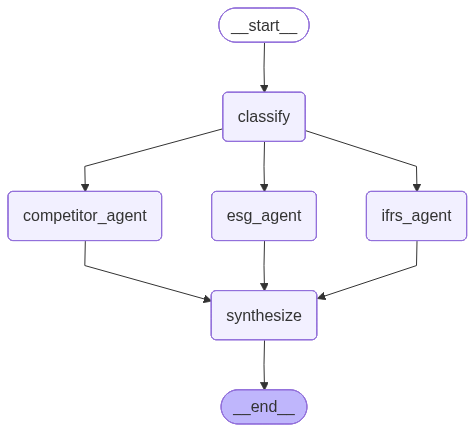

In [1]:
from graph import build_graph, GraphState

main_graph = build_graph()

# Visualise the graph (requires graphviz)
try:
    from IPython.display import Image, display
    display(Image(main_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(main_graph.get_graph().draw_mermaid())


## 3. Helper — invoke with pretty output

In [7]:
import uuid

_chat_history = []   # persists across ask() calls within the session

def ask(query: str, thread_id: str | None = None, approve_web: bool = False, reset_history: bool = False):
    """
    Run the RAG pipeline for a query.
    - approve_web=True    allow DuckDuckGo fallback when no internal source matches.
    - reset_history=True  clear the conversation history before this turn.
    """
    global _chat_history
    if reset_history:
        _chat_history = []

    thread_id = thread_id or str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}

    initial: GraphState = {
        "query": query,
        "sources": [],
        "agent_results": {},
        "final_answer": "",
        "needs_clarification": False,
        "clarification_question": None,
        "web_permission_required": False,
        "web_approved": False,
        "chat_history": _chat_history,
    }

    result = main_graph.invoke(initial, config=config)

    print(f"Sources detected : {result['sources'] or ' — '}")
    print("-" * 60)

    if result.get("needs_clarification"):
        cq = result.get("clarification_question", "Could you clarify?")
        print(f"[Clarification needed]\n{cq}")
        return result

    if result.get("web_permission_required"):
        print("[No internal sources found]")
        if approve_web:
            print("[Web search approved — searching internet …]\n")
            result = main_graph.invoke(
                {**initial, "web_approved": True}, config=config
            )
        else:
            print("Set approve_web=True to allow internet search.")
            return result

    answer = result.get("final_answer", "")
    print(answer)
    print()
    print("─" * 60)
    print("Was this answer helpful? Would you like me to explore other data sources?")

    # Update history for next turn
    _chat_history = result.get("chat_history", _chat_history)
    return result


## 4. Demo Queries

### 4a. Cross-source query (IFRS + Competitor)

In [8]:
result = ask(
    "What are the latest changes in IFRS related to financial statement presentation, "
    "and how are competitors adapting to it?"
)

Sources detected : ['ifrs', 'competitor']
------------------------------------------------------------
The latest changes in IFRS related to financial statement presentation are primarily driven by the introduction of **IFRS 18 Presentation and Disclosure in Financial Statements**, issued by the IASB in April 2024. This new standard supersedes IAS 1 and brings several significant updates aimed at enhancing the clarity, comparability, and usefulness of financial statements (IFRS Standards source).

### Key Changes under IFRS 18:
- **Statement of Profit or Loss**: Introduction of mandatory subtotals and revised classification of income and expenses to improve transparency.
- **Aggregation and Disaggregation**: New requirements on how financial information is grouped or separated, enabling users to better understand the components of financial performance.
- **Management-Defined Performance Measures**: Enhanced disclosure requirements for performance metrics defined by management, increas

### 4b. ESG-only query

In [ ]:
result = ask(
    "How should a company calculate its Scope 2 greenhouse gas emissions "
    "under the GHG Protocol, and what are the market-based vs location-based approaches?"
)

Sources detected : ['esg']
------------------------------------------------------------
Under the Greenhouse Gas (GHG) Protocol Corporate Standard, a company calculates its Scope 2 greenhouse gas emissions by quantifying the indirect emissions resulting from the generation of purchased electricity, steam, heating, and cooling consumed by the company. This involves multiplying the amount of energy consumed (activity data) by an appropriate emission factor that represents the greenhouse gas emissions per unit of energy (GHG Protocol, pp. 44, 61).

The GHG Protocol mandates reporting Scope 2 emissions using two distinct approaches, each reflecting different perspectives on emissions accounting:

1. **Location-Based Approach**  
   This approach calculates emissions based on the average emissions intensity of the electricity grid(s) where the energy consumption occurs. It uses grid-average emission factors that represent the typical generation mix (e.g., coal, natural gas, renewables) in t

### 4c. All-three-sources query

In [9]:
result = ask(
    "What ESG disclosures are required under IFRS and how does Pfizer report "
    "its environmental commitments in its annual report?"
)

Sources detected : ['esg', 'ifrs', 'competitor']
------------------------------------------------------------
Final Answer:

Under the current IFRS framework, there are no explicit, standalone ESG disclosure requirements mandated as part of the financial statements. According to the IFRS Standards overview, ESG-related information is disclosed only if it is material to the entity’s financial position or performance and relevant to users of financial statements (IFRS Standards source). This means that environmental, social, and governance factors are integrated into disclosures when they have a direct financial impact or risk implication. IAS 1 and IFRS presentation and disclosure requirements may encompass ESG matters if they influence judgments or accounting policies, but there is no dedicated ESG reporting standard within IFRS at present.

However, the IFRS Foundation has recently introduced IFRS Sustainability Disclosure Standards (not yet fully implemented), specifically IFRS S1 an

### 4d. Ambiguous query — clarification prompt

In [10]:
result = ask("Tell me about standards.")

Sources detected : —
------------------------------------------------------------
[Clarification needed]
Which type of standards are you referring to: ESG standards, IFRS accounting standards, or competitor-related standards?


### 4e. Web fallback — no internal sources

In [11]:
result = ask(
    "What is the current stock price of Pfizer and latest analyst recommendations?",
    # "Who is Napoleon?",

    approve_web=True
)

Sources detected : ['competitor']
------------------------------------------------------------
[Clarification needed]
Are you asking for the most recent stock price and analyst recommendations as of today, or for a specific date or period?


### 4f. Follow-up / feedback loop

In [ ]:
tid = str(uuid.uuid4())
result = ask("Explain the operating/investing/financing classification in IFRS 18.", thread_id=tid)

print("\n" + "=" * 60)
print("FOLLOW-UP")
print("=" * 60 + "\n")
result = ask(
    "Can you give an example of how a financial institution would classify "
    "interest income under IFRS 18?",
    thread_id=tid
)

## 5. Inspect raw agent outputs

In [ ]:
from graph import GraphState, build_graph
import uuid

g = build_graph()
state: GraphState = {
    "query": "What are the key disclosure requirements in IFRS 18?",
    "sources": [], "agent_results": {}, "final_answer": "",
    "needs_clarification": False, "clarification_question": None,
    "web_permission_required": False,
}
result = g.invoke(state, config={"configurable": {"thread_id": str(uuid.uuid4())}})

print("Detected sources:", result["sources"])
print()
for src, ans in result["agent_results"].items():
    print(f"--- {src.upper()} AGENT ---")
    print(ans[:800], "..." if len(ans) > 800 else "")
    print()

In [9]:
from graph import _get_web_agent
from langchain_core.messages import HumanMessage

state = {"query": "What is the latest news on AI?"}
result = _get_web_agent().invoke({"messages": [HumanMessage(content=state["query"])]})
result

{'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}, id='4ba63366-04a1-4e77-b701-a43dbd25471d'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 95, 'total_tokens': 112, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_8305e94f21', 'id': 'chatcmpl-DV21uO8xY0szsYLpdVbQkyWtIIaxO', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d9309-2035-7023-96d8-e2a08f3ddc90-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'latest news on AI'}, 'id': 'call_3OWATQo3mOZeM7f8P7khxRqi', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_token

# faiss make sure

In [17]:
from pathlib import Path
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from settings import BaseLLMSettings

s = BaseLLMSettings()
embeddings = OpenAIEmbeddings(model=s.EMBEDDING_MODEL, api_key=s.OPENAI_API_KEY)

query = "What are the five categories for classifying income and expenses in IFRS 18?"
query = "List all five income/expense categories introduced by IFRS 18 as a bullet list."
vs = FAISS.load_local(
    str(Path(s.FAISS_INDEX_DIR) / "ifrs"),
    embeddings, allow_dangerous_deserialization=True
)
chunks = vs.similarity_search(query, k=4)

In [39]:
print(docs[0].page_content)

IFRS Accounting Standards 
in Practice
IFRS 18 Presentation and Disclosure in Financial Statements 
(Presentation in the Statement of Profit or Loss)
2024/2025

[Visual Content]
The document page contains no tables, charts, diagrams, flowcharts, or figures. 

The visual content consists of a photograph showing a person paragliding with a red parachute over a mountainous landscape under a partly cloudy sky. The mountains are green and blue, indicating distance and depth. 

Text content on the page includes:
- Title in large red font: "IFRS Accounting Standards in Practice"
- Subtitle in smaller black font: "IFRS 18 Presentation and Disclosure in Financial Statements (Presentation in the Statement of Profit or Loss)"
- Year "2024/2025" in black font
- The logo "BDO" in white font on a red triangular background in the bottom right corner.

No other visual elements such as tables or charts are present on this page.


In [41]:
print(docs[1].page_content), print(docs[2].page_content)

Contents
1.	 Introduction.. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 5
1.1.	 Overview of changes introduced by IFRS 18. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 5
1.2.	 Background on Primary Financial Statements Project. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 5
2.	 Overview.. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 7
2.1.	 Key changes introduced by IFRS 18. . . . . . . . . . . . . . . . . . . . . . . . . . .

(None, None)

In [60]:
print(docs[47].page_content)

2.	Overview
For a brief summary of IFRS 18 (and all IFRS Accounting Standards), refer to BDO’s IFRS Accounting Standards At 
a Glance publication. 
2.1.	Key changes introduced by IFRS 18
Note that this section is not an exhaustive summary of all the effects of IFRS 18 and consequential amendments. 
The most significant effects of IFRS 18 (and consequential amendments to IFRS Accounting Standards other than 
IFRS 18) relate to the following topics:
Key changes
Summary
Classification of income 
and expenses in the 
statement of profit or 
loss
All income and expenses are classified into one of five categories: 
 
X The investing category
 
X The financing category
 
X The operating category
 
X The income taxes category
 
X The discontinued operations category
Income and expenses are generally classified based on the characteristic of the expense 
(i.e. the type of asset or liability to which the income or expense relates); however, certain


In [59]:
docs[47].metadata

{'source_type': 'ifrs',
 'filename': 'IFRS-18-Presentation-and-Disclosure-in-Financial-Statements.pdf',
 'page': 7}

In [37]:
docs[0].metadata

{'source_type': 'ifrs',
 'filename': 'IFRS-18-Presentation-and-Disclosure-in-Financial-Statements.pdf',
 'page': 1}

In [34]:
docs = list(vs.docstore._dict.values())
# Get all docs from the docstore
for  doc in docs:
    # print(f"ID: {doc_id}")
    print(f"Content: {doc.page_content}")
    # print(f"Metadata: {doc.metadata}")
    print("-" * 50)

Content: IFRS Accounting Standards 
in Practice
IFRS 18 Presentation and Disclosure in Financial Statements 
(Presentation in the Statement of Profit or Loss)
2024/2025

[Visual Content]
The document page contains no tables, charts, diagrams, flowcharts, or figures. 

The visual content consists of a photograph showing a person paragliding with a red parachute over a mountainous landscape under a partly cloudy sky. The mountains are green and blue, indicating distance and depth. 

Text content on the page includes:
- Title in large red font: "IFRS Accounting Standards in Practice"
- Subtitle in smaller black font: "IFRS 18 Presentation and Disclosure in Financial Statements (Presentation in the Statement of Profit or Loss)"
- Year "2024/2025" in black font
- The logo "BDO" in white font on a red triangular background in the bottom right corner.

No other visual elements such as tables or charts are present on this page.
--------------------------------------------------
Content: Conten

In [16]:
vs

In [18]:
for i, doc in enumerate(chunks, 1):
    has_table  = "[TABLE]"          in doc.page_content
    has_vision = "[Visual Content]" in doc.page_content
    tag = " | ".join(filter(None, ["TABLE" if has_table else "", "VISION" if has_vision else ""]))
    print(f"\n{'─'*60}")
    print(f"Chunk {i}  [{tag or 'text only'}]  — {doc.metadata['filename']} p.{doc.metadata['page']}")
    print(doc.page_content[:600])



────────────────────────────────────────────────────────────
Chunk 1  [text only]  — IFRS-18-Presentation-and-Disclosure-in-Financial-Statements.pdf p.10
The text explains that IFRS 18 requires classification of all income and expense items into five categories: investing, financing, operating, income taxes, and discontinued operations, with references to sections 3.2 through 3.6 for each category. It also mentions that the structure of the statement of profit or loss depends on how items are classified and provides an example of a typical statement for an entity without specified main business activities.

────────────────────────────────────────────────────────────
Chunk 2  [text only]  — IFRS-18-Presentation-and-Disclosure-in-Financial-Statements.pdf p.63
The following section provides practical guidance on the classification of common items of income and expense 
applying the requirements of IFRS 18. Where the classification of the items may differ depending on whether an 
entity 

In [ ]:
# Requires a table (IFRS-18 p.7 key-changes table)
"List all five income/expense categories introduced by IFRS 18 as a bullet list."

# Requires a GHG table (global warming potential values)
"What is the 100-year global warming potential of HFC-23 according to IPCC values?"

# Requires vision (a chart or diagram page)
"Describe any diagram or figure that explains the GHG Protocol accounting boundary."

# Requires competitor table (Pfizer financial data)
"What specific revenue figures appear in Pfizer's annual report tables?"


Document(id='0725c39a-64dc-46b6-a366-686d0489a2de', metadata={'source_type': 'ifrs', 'filename': 'IFRS-18-Presentation-and-Disclosure-in-Financial-Statements.pdf', 'page': 10}, page_content='3.\tClassification of Income and expenses\n3.1.\tGeneral considerations \n3.1.1.\t Classification of income and expenses - general requirements \nIFRS 18 requires entities to classify all items of income and expense into one of five categories (IFRS 18.47):\n \nX The investing category (section 3.2)\n \nX The financing category (section 3.3)\n \nX The operating category (section 3.4)\n \nX The income taxes category (section 3.5)\n \nX The discontinued operations category (section 3.6)\nThe structure of the statement of profit or loss is then based upon how items of income and expense are classified. \nFor example, for an entity without specified main business activities where certain exceptions to the classification \nrequirements apply (see section 3.8), a typical statement of profit or loss may b